## Processing of LLM Output

Talks about why we need to convert the LLM's normal text response into a structured format when we want the LLM to communicate with software, APIs, databases, or agents.

What if we can make LLM talk with other machines or systems?

Earlier we learned about prompts (Input to LLM), today we will learn about output from LLM

Normally, an LLM works like:

User Prompt -> LLM -> Text Response

Example-

User: Give me a one-day itinerary for Paris.

## LLM Unstructured Output

- Morning: Visit the Eiffel Tower.
- Afternoon: Walk through the Louvre Museum.
- Evening: Have dinner near the Seine.


This is perfectly understandable to a human. But a computer doesn't automatically know:

Morning → activity, Afternoon → activity, Evening → activity

It's just a block of text.

Therefore, Textual output is unstructured.


## LLM Structured Output 

Instead, we can ask the LLM to return something structured, such as JSON.

In [ ]:
[
  {
    "time": "Morning",
    "activity": "Visit the Eiffel Tower"
  },
  {
    "time": "Afternoon",
    "activity": "Walk through the Louvre Museum"
  },
  {
    "time": "Evening",
    "activity": "Enjoy dinner at a Seine riverside café"
  }
]

# Now the output has a defined structure and we know time and activity are fields

[{'time': 'Morning', 'activity': 'Visit the Eiffel Tower'},
 {'time': 'Afternoon', 'activity': 'Walk through the Louvre Museum'},
 {'time': 'Evening', 'activity': 'Enjoy dinner at a Seine riverside café'}]

## What does "unstructured" mean?

Unstructured means that the information doesn't follow a fixed machine-readable format.

For example:

Morning: Visit the Eiffel Tower.

Afternoon: Walk through the Louvre Museum.

Evening: Enjoy dinner at a Seine riverside café.

A human can easily understand this.But suppose your Python program needs:

itinerary["Morning"]

How does Python know which part is "Morning"? It would have to parse the text manually.

That's inconvenient and error-prone.

## Human vs Machine

This is the central idea of the lecture.

In [2]:
# Unstructured output:

# LLM
#  ↓
# "Morning: Visit Eiffel Tower.
#  Afternoon: Visit Louvre..."
#  ↓
#  Human understands it


# Structured output
# LLM
#  ↓
# JSON
#  ↓
# Python / API / Database / Agent
# The second one is much easier for software to work with.

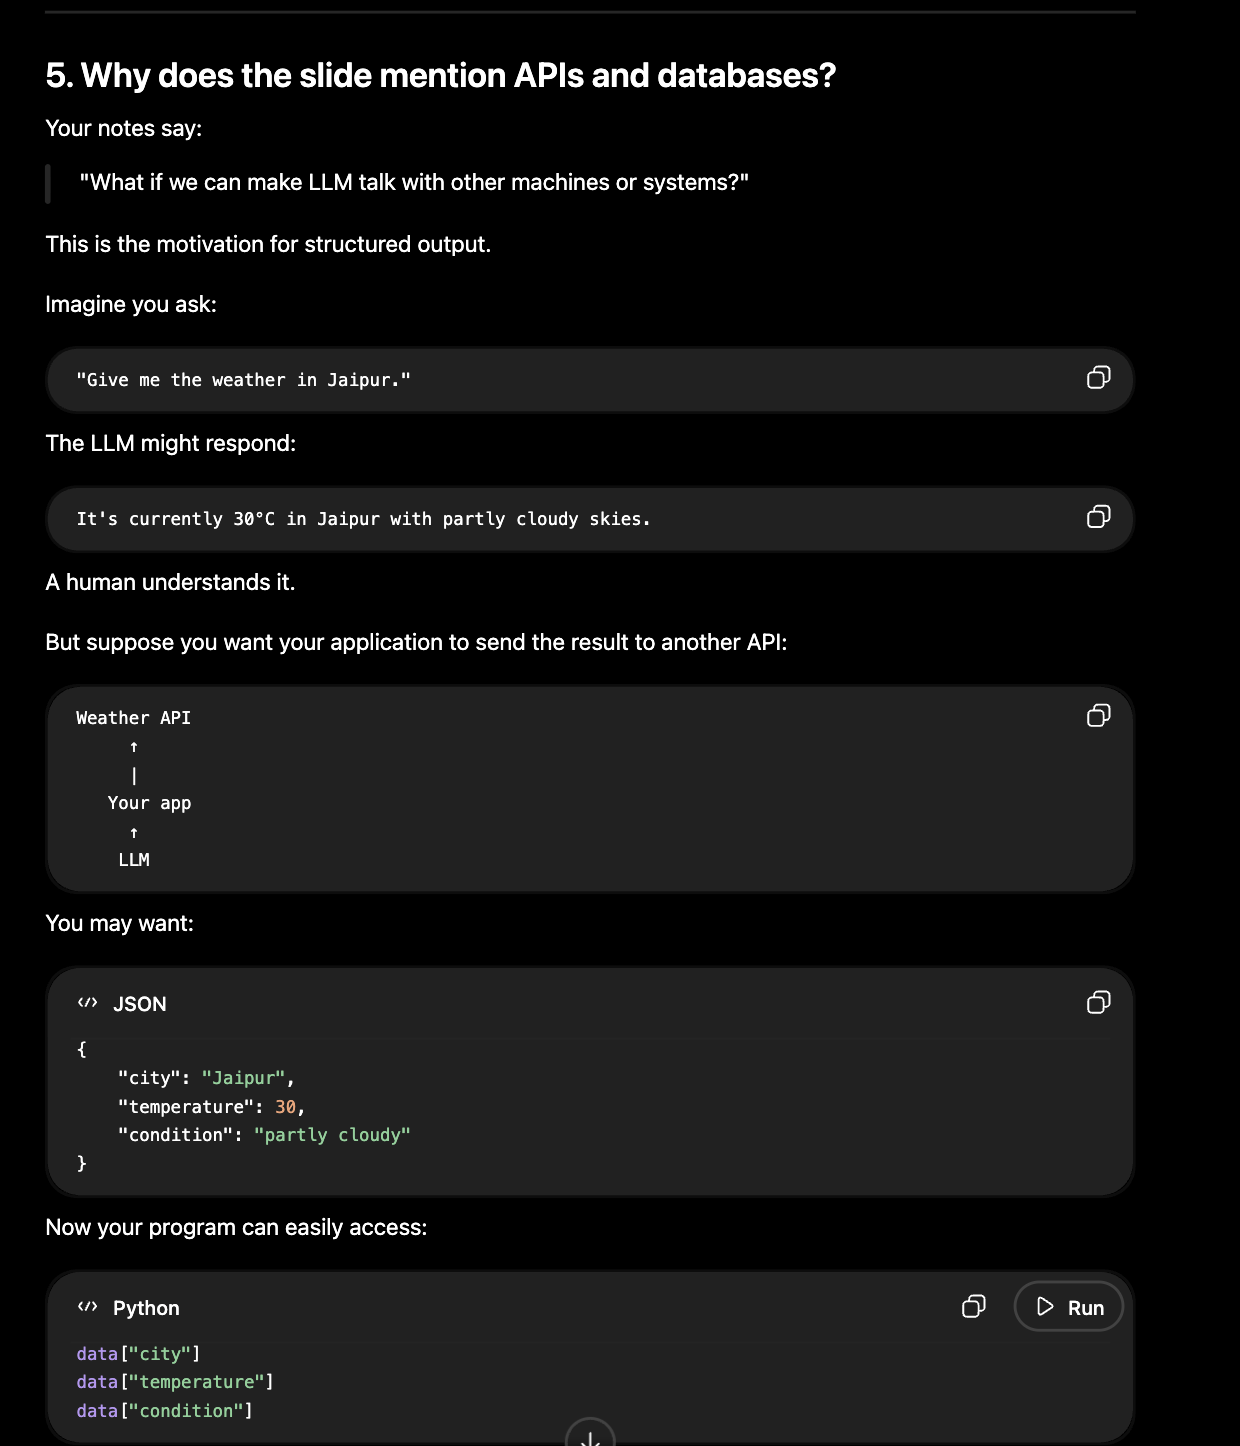

## Why is this important for Agents?

An agent isn't just generating text.

Understand user request -> Decide what action to take -> Call a tool/API/database -> Receive result -> Continue Reasoning -> Give final answer

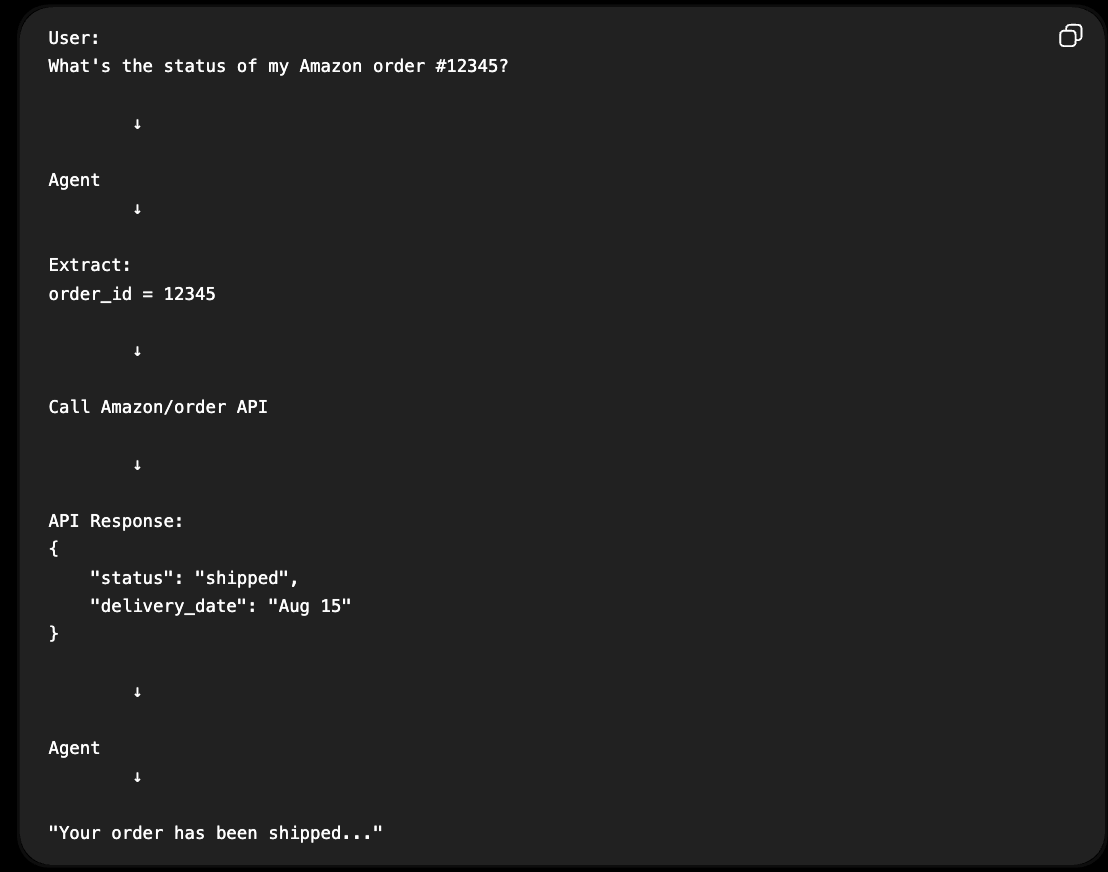

## LLM Output processing 

LLM Produces output -> we process/convert it -> application can use it

## Why JSON ?

JSON is one of the most common structured formats used between software systems. So JSON makes the LLM output machine-readable.

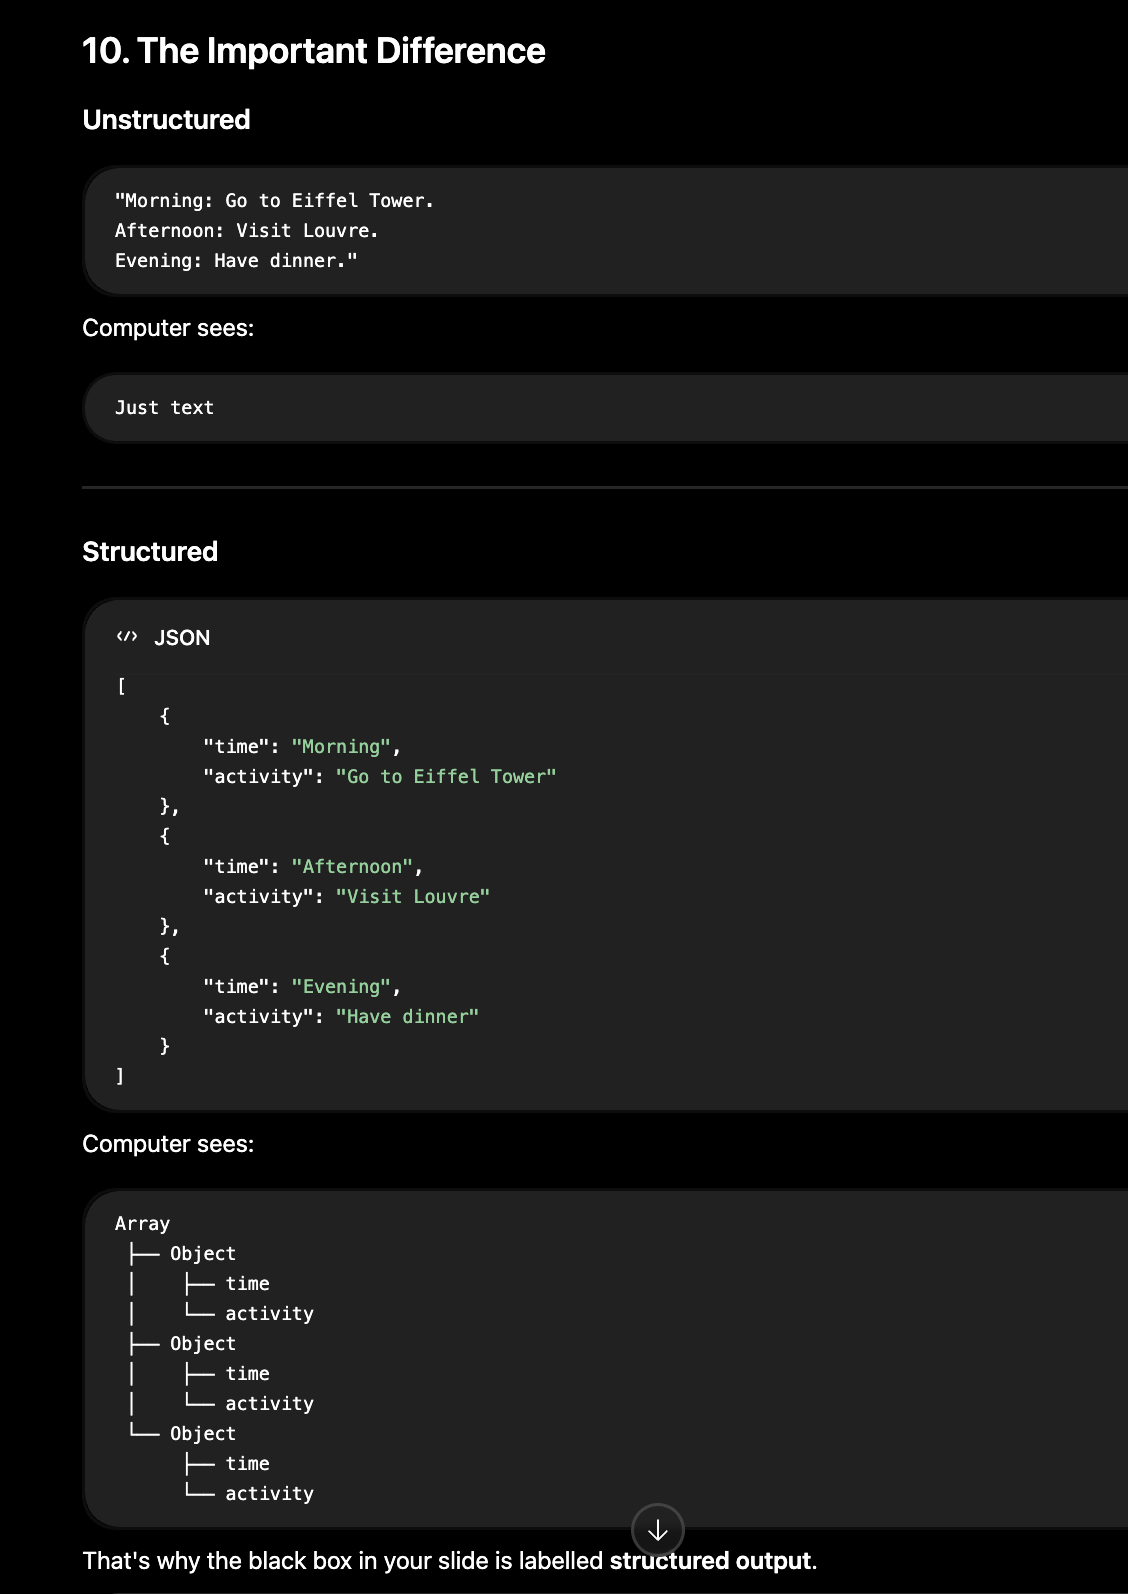

## Structured Output

In Langchain, structured output refers to the practice of having language models return responses in a well defined data format (example JSON) rather than free-form text. This makes the model output easier to parse and work with progammatically.

## Why Do We Need Structured Output?

Structured output is needed when the LLM's response has to be consumed by another software system, rather than just displayed to a human.

The three important use cases are:

1-Data Extraction

2-API Building

3-Agents

# 1.Data Extraction

Extract information from unstructured text → convert it into structured data → store it in a database.


Suppose you are building a job portal 

A candidate uploads a resume:

Resume -> Extract text -> LLM -> Structured JSON -> Store it in Database

In [ ]:
# The resume is unstructured text:

# Priyanshu Gupta
# Software Engineer
# B.Tech ...
# 12th: 92%
# Previous Company: ABC
# ...

# You want to extract specific information:

# {
#     "name": "Priyanshu Gupta",
#     "last_company": "ABC",
#     "twelfth_marks": 92,
#     "college": "..."
# }

# Now your Python code can easily access:

# data["name"], data["last_company"], data["twelfth_marks"]
# and insert these values into your database.
# A database has a fixed structure.

# For example: Candidates Table

# id | name | company | marks | college
# --------------------------------------
# 1  | ...  | ...     | ...   | ...

# If the LLM simply gives:

# "The candidate is Priyanshu. He scored 92% in 12th..."

# your code has to figure out where each piece of information is.

# But with JSON:
#     {
#     "name": "Priyanshu",
#     "marks": 92
# }

# the mapping becomes straightforward:

# JSON field       → Database column

# name             → name
# marks            → marks
# college          → college
# company          → company

## 2. API Building

Suppose you work for Amazon and Amazon has millions of product reviews.

A review might be:

"The phone has an amazing camera and the battery lasts all day.
However, the phone gets quite hot while gaming."

A human can understand this immediately.But your application might want these specific fields:

1.Topic

2.Pros

3.Cons

4.Sentiment

So the LLM can convert the review into:


In [ ]:
{
    "topic": "Phone",
    "pros": [
        "Amazing camera",
        "Good battery life"
    ],
    "cons": [
        "Gets hot while gaming"
    ],
    "sentiment": "positive"
}
# Now you have structured information.

{'topic': 'Phone',
 'pros': ['Amazing camera', 'Good battery life'],
 'cons': ['Gets hot while gaming'],
 'sentiment': 'positive'}

Suppose you create a service:

POST /analyze-review

A client sends:

JSON:
{

    "review": "The camera is amazing but the phone gets hot."
    
}


Backend:

Client -> FastAPI/Flask -> LLM -> Structured Output -> JSON Response -> Client 

The API returns:

{
    "topic": "Smartphone",

    "pros": ["Amazing camera"],

    "cons": ["Gets hot"],

    "sentiment": "mixed"
}

Now any application that can call your API can use this service.

For example:

Mobile, Website, Another backend, Data Pipeline, Dashboard

## 3. Agents

An agent doesn't just generate an answer.

Agent:

User's natural language -> Agent -> Structured instruction -> Database tool ->
Database result -> Agent -> Human-readable answer

## Example 1: Calculator

Suppose the user says:

"Find the square root of 2."

The user input is: Find the square root of 2

But the calculator tool may expect: sqrt(2)

It doesn't necessarily understand natural language.

So we need the agent/LLM to understand the request and extract the useful information.

User-> "Find square root of 2" -> LLM / Agent -> Structured information -> number = 2, operation = sqrt -> Calculator -> 1.414

Structured Output acts like a bridge. 

The tool needs structured input:

{
    "operation": "sqrt",

    "number": 2
}

The LLM acts as the translator:

Natural Language -> LLM -> Structured Data -> Tool

This is why structured output is so important for agents.

## Example 2: Database

Suppose the user asks:

"Show me all employees whose salary is greater than 10 lakh."

The database needs something structured, such as a SQL query or tool arguments.

The agent can determine:

{

    "condition": "salary > 1000000"

}

Then the appropriate database tool can execute the query.

User's natural language -> Agent -> Structured instruction -> Database tool -> Database result -> Agent -> Human-readable answer

## Two types of LLMs

***Type 1 — LLMs that support structured output:***

Some modern LLMs have a capability to return responses according to a specified structure/schema.

you ask for:

{
    "name": "John",
    "age": 25
}

and the model can natively follow that structure.

***Type 2 — LLMs that don't support structured output:***

Some models don't have native structured-output support.

They naturally return:

John is 25 years old and works as a software engineer.

So LangChain needs another mechanism to convert/parse this output into the structure your application wants.

## LangChain provides two approaches

In [ ]:
#                          LLM
#                           |
#               ┌───────────┴───────────┐
#               ↓                       ↓
#        Supports structured       Doesn't support
#             output                structured output
#               ↓                       ↓
#  with_structured_output()       Output Parsers
#               ↓                       ↓
#        Structured data        Parse/convert output


# So you should remember:

# Native structured-output-capable model → with_structured_output()

# Model without native structured-output support → Output Parsers

## with_structured_output():

The first approach is: model.with_structured_output(...)

This is a LangChain function/method provided for models that support structured output.

The idea is:

"Here is the format/schema I want. Make the model return its output according to this structure."

In [ ]:
# We call with_structured_output() before invoking the model and we mention the format which we want
# Model supports structured output
#         ↓
# with_structured_output(schema)
#         ↓
# invoke()
#         ↓
# Structured result 


# Model doesn't support structured output
#         ↓
# LLM generates text
#         ↓
# Output Parser
#         ↓
# Structured result

## 3 Ways to specify data format

1-TypedDict

2-Pydantic

3-JSON Schema

# TypedDict

TypedDict is a way to define a dictionary where you specify what keys and values should exist. It helps ensure that your dictionary follows a specific structure.

In [ ]:
person={'name':'Nitish', 'age':35}

# Suppose two programmers are working on the same project.
# one programmer expects age to be int but But another programmer might provide: age = "25"
# where age is a str.

# Both contain 25, but they are different data types.

# This can cause problems later:

# age + 5

Idea : We should define the expected structure and data types beforehand.

In [ ]:
"You make a class to form dictionary."

from typing import TypedDict

class Person(TypedDict):
    name:str
    age:int

p1=Person(name='ramesh',age=50)
## We are defining the expected keys and their types.

# We Tell LangChain:
# Generate the LLM's response according to this structure.


# Why use TypedDict ?

1- It tells python what keys are required and what types of value they should have

2- It doesn't validate the data at runtime (it just helps with type hints for better coding)

In [ ]:
## 2nd point meaning
## we can still assign age as str though it is mentioned it should be str

p2=Person(name='Ravi',age="30")
p2

{'name': 'Ravi', 'age': '30'}

In [ ]:
# structured_model=model.with_structured_output(Person)

# Person is your data format/schema.

# Example: Review 

In [12]:
# Review
#    ↓
# LLM
#    ↓
# {
#    summary: ...
#    sentiment: ...
# }

In [16]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict

load_dotenv()


True

In [22]:
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')

## class Review 

class Review(TypedDict):
    summary:str
    sentiment:str

structured_model=model.with_structured_output(Review)
result=structured_model.invoke("The hardware is great but software feels bloated. There are too many preinstalled apps that I can't remove. Also, UI looks outdated compared to other brands. Hoping for a software update to fix this")
print(result)

{'summary': 'The user likes the hardware but finds the software bloated, with too many unremovable preinstalled apps and an outdated UI, hoping for a future software update.', 'sentiment': 'Mixed'}


In [24]:
type(result)

dict

In [26]:
print(result['sentiment'])

Mixed


In [ ]:
## Surprising Fact: I haven't written in my prompt that I need summary and sentiment 
## still the model is able to understand it. 

## When you provide a schema to model, behind the scene SystemPrompt is generated

System Prompt looks like this:

You are an AI assistant that extracts structured insights from text.
Given a product review, extract: Summary: A brief overview of the main points. Sentiment: Overall tone of the review( positive, negative, mixed). Return the response in json format

Types of TypedDict:

1-SimpleTypedDict

2-Annotated TypedDict

3-Literal

4-More complex ->pros and cons

In [ ]:
from typing import Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict,Annotated

## class Review 

class Review(TypedDict):
    summary:Annotated[str,"A brief summary of the review"]
    sentiment:Annotated[str,"Returns either negative or positive or Mixed"]

structured_model=model.with_structured_output(Review)
result=structured_model.invoke("The hardware is great but software feels bloated. There are too many preinstalled apps that I can't remove. Also, UI looks outdated compared to other brands. Hoping for a software update to fix this")
print(result)

{'summary': 'The user appreciates the hardware quality but is dissatisfied with the bloated software, unremovable preinstalled apps, and outdated UI, hoping for a software update to resolve these issues.', 'sentiment': 'Mixed'}


In [30]:
from typing import Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict,Annotated,Optional,Literal

## class Review 

class Review(TypedDict):
    key_themes:Annotated[list[str],'Write down all the key themes discuseed in the review in a list']
    summary:Annotated[str,"A brief summary of the review"]
    sentiment:Annotated[Literal["pos","neg"],"Returns either negative or positive or Mixed"]
    pros:Annotated[Optional[list[str]],"Write down all the pros inside a list"]
    cons:Annotated[Optional[list[str]],"Write down all the cons inside a list"]


structured_model=model.with_structured_output(Review)
result=structured_model.invoke('''
I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:

Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful

Cons:

Bulky and heavy—not great for one-handed use
Bloatware still exists in One UI
Expensive compared to competitors
''')
print(result)

{'key_themes': ['Performance', 'Battery Life', 'Camera', 'Design & Size', 'Software', 'Pricing'], 'summary': 'The Samsung Galaxy S24 Ultra is an exceptionally fast and capable flagship smartphone featuring an incredible 200MP camera system, excellent battery life, and S-Pen integration, though its large size, high price, and pre-installed bloatware may deter some users.', 'sentiment': 'pos', 'pros': ['Insanely powerful Snapdragon 8 Gen 3 processor', 'Stunning 200MP camera with incredible low-light and zoom capabilities', 'Long battery life with 45W fast charging', 'Useful integrated S-Pen'], 'cons': ['Bulky and heavy design makes one-handed use uncomfortable', 'Contains pre-installed Samsung bloatware', 'High price tag of $1,300']}


In [ ]:
from typing import Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict,Annotated,Optional,Literal

## class Review 

class Review(TypedDict):
    key_themes:Annotated[list[str],'Write down all the key themes discuseed in the review in a list']
    summary:Annotated[str,"A brief summary of the review"]
    sentiment:Annotated[Literal["pos","neg"],"Returns either negative or positive or Mixed"]
    pros:Annotated[Optional[list[str]],"Write down all the pros inside a list"]
    cons:Annotated[Optional[list[str]],"Write down all the cons inside a list"]
    name:Annotated[Optional[str],"Write the name of reviewer"]


structured_model=model.with_structured_output(Review)
result=structured_model.invoke('''
I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:

Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful

Cons:

Bulky and heavy—not great for one-handed use
Bloatware still exists in One UI
Expensive compared to competitors
''')
print(result)

## there is not gurantee that if you mention in typeddict you want str, you will surely get a string
## possible LLM can make mistake and give data in different format 

{'key_themes': ['Performance', 'Camera Quality', 'Battery Life', 'S-Pen Integration', 'Design & Ergonomics', 'Software & Bloatware', 'Pricing'], 'summary': 'The Samsung Galaxy S24 Ultra is a powerful flagship smartphone offering top-tier performance, excellent battery life, a versatile 200MP camera system, and S-Pen support, though its high price, bulky design, and pre-installed bloatware remain notable drawbacks.', 'sentiment': 'pos', 'pros': ['Insanely powerful processor (great for gaming and productivity)', 'Stunning 200MP camera with incredible zoom capabilities', 'Long battery life with fast charging', 'S-Pen support is unique and useful'], 'cons': ['Bulky and heavy—not great for one-handed use', 'Bloatware still exists in One UI', 'Expensive compared to competitors'], 'name': 'Samsung Galaxy S24 Ultra'}


You cannot apply Data Validation in TypedDict

This is just used for Representation Purpose

## Pydantic

Pydantic is a data validation and data parsing library for Python. It ensures that the data you work with is correct, structured, and type-safe

In simple words, Pydantic lets you define what your data should look like and then checks whether the actual data follows those rules.

In [34]:
from pydantic import BaseModel
class Student(BaseModel):
    name:str
    marks:int


new_student={'name':'Priyanshu','marks':32}

student=Student(**new_student)

print(student)

name='Priyanshu' marks=32


In [40]:
## Alternative way of writing

from pydantic import BaseModel
class Student(BaseModel):
    name:str
    marks:int


new_student=Student(name='Priyanshu',marks=32)

print(new_student)

name='Priyanshu' marks=32


The Student class inherits from BaseModel.

This gives the class Pydantic's validation and parsing capabilities.

In [36]:
type(student)
## it is a pydantic object as it inherits from BaseModel class

__main__.Student

In [ ]:
n_std={'name':'Priya','age':'46'}

std=Student(**n_std)
print(std)

## Gives Error

# ValidationError: 1 validation error for Student
# name
# Input should be a valid integer

ValidationError: 1 validation error for Student
marks
  Field required [type=missing, input_value={'name': 'Priya', 'age': '46'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

## Default values in Pydantic

In [41]:
class Student(BaseModel):
    name:str = 'Priyanshu'


new_student={}
student=Student(**new_student)

print(student)


name='Priyanshu'


In [42]:
student.name

'Priyanshu'

In [ ]:
#            Incoming data
#                     ↓
#             ┌───────────────┐
#             │   Pydantic    │
#             │   Validator   │
#             └───────┬───────┘
#                     ↓
#              Does it match
#                 schema?
#                /       \
#              YES        NO
#               ↓          ↓
#           Model       ValidationError

## Optional Fields in Pydantic

In [43]:
from pydantic import BaseModel
from typing import Optional
class Student(BaseModel):
    name:str='Laila'
    age:Optional[int]=None


new_student={}

student=Student(**new_student)

print(student)

name='Laila' age=None


In [44]:
from pydantic import BaseModel
from typing import Optional
class Student(BaseModel):
    name:str='Laila'
    age:Optional[int]=None


new_student={'age':32}

student=Student(**new_student)

print(student)

name='Laila' age=32


## Type Coercing in Pydantic 

Pydantic Can convert wrong datatype to the correct mentioned datatype

In [45]:
from pydantic import BaseModel
from typing import Optional
class Student(BaseModel):
    name:str='Laila'
    age:Optional[int]=None


new_student={'age':'32'} ## Pydantic can convert it into int

student=Student(**new_student)

print(student)



name='Laila' age=32


## Builtin Validation for Emails


In [46]:
from pydantic import BaseModel,EmailStr
from typing import Optional
## EmailStr is a datatype builtin Pydantic 
class Student(BaseModel):
    name:str='Laila'
    age:Optional[int]=None
    email:EmailStr

new_student={'age':32,'email':'abc'}

student=Student(**new_student)

ValidationError: 1 validation error for Student
email
  value is not a valid email address: An email address must have an @-sign. [type=value_error, input_value='abc', input_type=str]

In [47]:
from pydantic import BaseModel,EmailStr
from typing import Optional
## EmailStr is a datatype builtin Pydantic 
class Student(BaseModel):
    name:str='Laila'
    age:Optional[int]=None
    email:EmailStr

new_student={'age':32,'email':'a@gmail.com'}

student=Student(**new_student)

## Field Function in Pydantic

- Can set Default values
- Can set Constraints
- Can give description to values
- can apply regular expressions

Constraint

In [48]:
from pydantic import BaseModel,EmailStr,Field
from typing import Optional
## EmailStr is a datatype builtin Pydantic 
class Student(BaseModel):
    name:str='Laila'
    age:Optional[int]=None
    email:EmailStr
    cgpa:float= Field(gt=0, lt=10)

new_student={'age':32,'email':'a@gmail.com','cgpa':12}

student=Student(**new_student)

ValidationError: 1 validation error for Student
cgpa
  Input should be less than 10 [type=less_than, input_value=12, input_type=int]
    For further information visit https://errors.pydantic.dev/2.13/v/less_than

In [51]:
from pydantic import BaseModel,EmailStr,Field
from typing import Optional
## EmailStr is a datatype builtin Pydantic 
class Student(BaseModel):
    name:str='Laila'
    age:Optional[int]=None
    email:EmailStr
    cgpa:float= Field(gt=0, lt=10)

new_student={'age':32,'email':'a@gmail.com','cgpa':8}

student=Student(**new_student)
print(student)

name='Laila' age=32 email='a@gmail.com' cgpa=8.0


Default Value

In [52]:
from pydantic import BaseModel,EmailStr,Field
from typing import Optional
## EmailStr is a datatype builtin Pydantic 
class Student(BaseModel):
    name:str='Laila'
    age:Optional[int]=None
    email:EmailStr
    cgpa:float= Field(gt=0, lt=10,default=7)

new_student={'age':32,'email':'a@gmail.com'}

student=Student(**new_student)
print(student)

name='Laila' age=32 email='a@gmail.com' cgpa=7


Custom Description

In [53]:
from pydantic import BaseModel,EmailStr,Field
from typing import Optional
## EmailStr is a datatype builtin Pydantic 
class Student(BaseModel):
    name:str='Laila'
    age:Optional[int]=None
    email:EmailStr
    cgpa:float= Field(gt=0, lt=10,default=7,description='Decimal value representing the cgpa of student')

new_student={'age':32,'email':'a@gmail.com'}

student=Student(**new_student)
print(student)

name='Laila' age=32 email='a@gmail.com' cgpa=7


Regular Expression

In [56]:
from pydantic import BaseModel,EmailStr,Field
from typing import Optional
## EmailStr is a datatype builtin Pydantic 
class Student(BaseModel):
    name:str='Laila'
    age:Optional[int]=None
    email:EmailStr
    cgpa:float= Field(gt=0, lt=10,default=7,description='Decimal value representing the cgpa of student')
    phone:str = Field(
    description="Indian mobile number with exactly 10 digits",
    pattern=r"^[6-9]\d{9}$" ## first digit must be 6,7,8 or 9 
    ## \d{9} next 9 characters must be digit
    ## $ represets end of the string

    )


new_student = {
    "age": 32,
    "email": "a@gmail.com",
    "phone": "9876543210"
}

student = Student(**new_student)

print(student)


name='Laila' age=32 email='a@gmail.com' cgpa=7 phone='9876543210'


In [58]:
# Convert pydantic into dict

d=dict(student)
d['phone']

'9876543210'

In [64]:
# convert pydantic to json
std_json=student.model_dump_json()
std_json

'{"name":"Laila","age":32,"email":"a@gmail.com","cgpa":7.0,"phone":"9876543210"}'

In [65]:
from typing import Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict,Annotated,Optional,Literal
from pydantic import EmailStr,Field,BaseModel

## class Review 

class Review(BaseModel):
    key_themes:list[str]= Field(description='Write down all the key themes discuseed in the review in a list')
    summary:str=Field(description='A brief summary of the review')
    sentiment:Literal["pos","neg"]=Field(description='Returns either negative or positive or Mixed')
    pros:Optional[list[str]]=Field(description='Write down all the pros inside a list',default=None)
    cons:Optional[list[str]]=Field(description="Write down all the cons inside a list",default=None)
    name:Optional[str]=Field(description="Write the name of reviewer")


structured_model=model.with_structured_output(Review)
result=structured_model.invoke('''
I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:

Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful

Cons:

Bulky and heavy—not great for one-handed use
Bloatware still exists in One UI
Expensive compared to competitors
''')
print(result)

## there is not gurantee that if you mention in typeddict you want str, you will surely get a string
## possible LLM can make mistake and give data in different format 

key_themes=['Performance', 'Battery Life', 'Camera Quality', 'S-Pen Integration', 'Design and Weight', 'Software and Bloatware', 'Pricing'] summary='The review praises the Samsung Galaxy S24 Ultra for its fast performance, excellent battery life, impressive 200MP camera, and S-Pen, while noting issues with its bulky design, pre-installed bloatware, and high price.' sentiment='pos' pros=['Insanely powerful processor (great for gaming and productivity)', 'Stunning 200MP camera with incredible zoom capabilities', 'Long battery life with fast charging', 'S-Pen support is unique and useful'] cons=['Bulky and heavy—not great for one-handed use', 'Bloatware still exists in One UI', 'Expensive compared to competitors'] name=None


In [68]:
result.cons

['Bulky and heavy—not great for one-handed use',
 'Bloatware still exists in One UI',
 'Expensive compared to competitors']

## JSON Vs JSON Schema

JSON: JSON is the actual data.

Example:

In [2]:
{
  "name": "Rahul",
  "age": 25
}

{'name': 'Rahul', 'age': 25}

JSON Schema: JSON Schema describes what the data is supposed to look like.

In [3]:
{
 "type":"object",
 "properties":{
     "name":{
         "type":"string"
     },
     "age":{
         "type":"integer"
     }
 },

 "required":["name"]

}

{'type': 'object',
 'properties': {'name': {'type': 'string'}, 'age': {'type': 'integer'}},
 'required': ['name']}

JSON -> Actual Data

JSON Schema -> Blueprint of the data

## What is JSON Schema?

A JSON Schema is a formal definition of what a JSON object should look like.

It tells us things such as:

- What fields should exist
- What type each field should have
- Which fields are required
- What values are allowed
- What the structure of nested data should be

Think of it as a blueprint for JSON data.

## Why JSON Schema is useful in Multi-language projects ?

Backend → Python, Frontend → JavaScript

Suppose your backend is written in Python:

Python Backend -> JSON -> JavaScript Frontend

Python and JavaScript are different programming languages, but both understand JSON. That's why JSON is useful as a common communication format.

For example, Python might send:

{
  "name": "Rahul",
  
  "age": 25
}

JavaScript can read the same JSON.

So you can think of JSON as a common language between different parts of a software system.

JSON is universal data format

To create a schema:

Add these things:

- title (title of the schema)
- description (Optional field)
- type (tells datatype)
- properties (attributes)
- required (same as optional)

In [5]:
from typing import Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict,Annotated,Optional,Literal
from pydantic import EmailStr,Field,BaseModel
load_dotenv()
## class Review 

json_schema={
    "title":"Review",
    "type":"object",
    "properties":
    {
        "key_themes":{
            "type":"array",
            "items":{"type":"string"},
            "description":"Write down all the key themes discussed"
        },
        "summary":{
            "type":"string",
            "description":"A brief summary of the review"
        },
        "sentiment":{
            "type":"string",
            "enum":["pos","neg"],
            "description":"Return either positive, negative or neutral"
        },
        "pros":{
            "type":["array","null"],
            "items":{
                "type":"string"
            },
            "description":"Write down all pros inside a list"
        },
        "cons":{
                    "type":["array","null"],
                    "items":{
                        "type":"string"
                    },
                    "description":"Write down all cons inside a list"
                },
        "name":{
            "type":["string","null"],
            "description":"Write the name of the reviewer"
        },
        "required":["key_themes","summary","sentiment"]
    }
}

model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')
structured_model=model.with_structured_output(json_schema)
result=structured_model.invoke('''
I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:

Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful

Cons:

Bulky and heavy—not great for one-handed use
Bloatware still exists in One UI
Expensive compared to competitors
''')
print(result)


ChatGoogleGenerativeAIError: Error calling model 'gemini-3.6-flash' (INVALID_ARGUMENT): 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'schema at properties.required must be a boolean or an object', 'status': 'INVALID_ARGUMENT'}}

In [16]:
from typing import Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict,Annotated,Optional,Literal
from pydantic import EmailStr,Field,BaseModel
load_dotenv()
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')
json_schema={
    "title":"Review",
    "type":"object",
    "properties":
    {
        "key_themes":{
            "type":"array",
            "items":{"type":"string"},
            "description":"Write down all the key themes discussed"
        },
        "summary":{
            "type":"string",
            "description":"A brief summary of the review"
        },
        "sentiment":{
            "type":"string",
            "enum":["pos","neg"],
            "description":"Return either positive, negative or neutral"
        },
        "pros":{
            "type":["array","null"],
            "items":{
                "type":"string"
            },
            "description":"Write down all pros inside a list"
        },
        "cons":{
                    "type":["array","null"],
                    "items":{
                        "type":"string"
                    },
                    "description":"Write down all cons inside a list"
                },
        "name":{
            "type":["string","null"],
            "description":"Write the name of the reviewer"
        }
    },
        "required": ["name"]

}

structured_model=model.with_structured_output(json_schema)
result=structured_model.invoke('''
I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.

The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.

However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:

Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful

Cons:

Bulky and heavy—not great for one-handed use
Bloatware still exists in One UI
Expensive compared to competitors
''')
print(result)

{'key_themes': ['Performance', 'Battery Life', 'Camera Quality', 'Design and Ergonomics', 'Software and Bloatware', 'Pricing'], 'summary': 'The Samsung Galaxy S24 Ultra is an exceptionally fast flagship device with remarkable battery life, superior camera quality, and S-Pen functionality, though it is held back slightly by its heavy build, pre-installed bloatware, and high cost.', 'sentiment': 'pos', 'pros': ['Insanely powerful processor (great for gaming and productivity)', 'Stunning 200MP camera with incredible zoom capabilities', 'Long battery life with fast charging', 'S-Pen support is unique and useful'], 'cons': ['Bulky and heavy—not great for one-handed use', 'Bloatware still exists in One UI', 'Expensive compared to competitors'], 'name': None}


## When to use what ?

Use TypedDict only if:

- You only need type hints (basic structure enforcement)
- You do not need validation (eg, checking the numbers are positive)
- You trust the LLM to return correct data

Use Pydantic only if:

- You need data validation 
- You need default values if LLM misses fields
- You want automatic type conversion

Use json_schema only if:

- You are working with multi-language project
- You want to define structure in a standard JSON format
- You need validation but do not need python objects

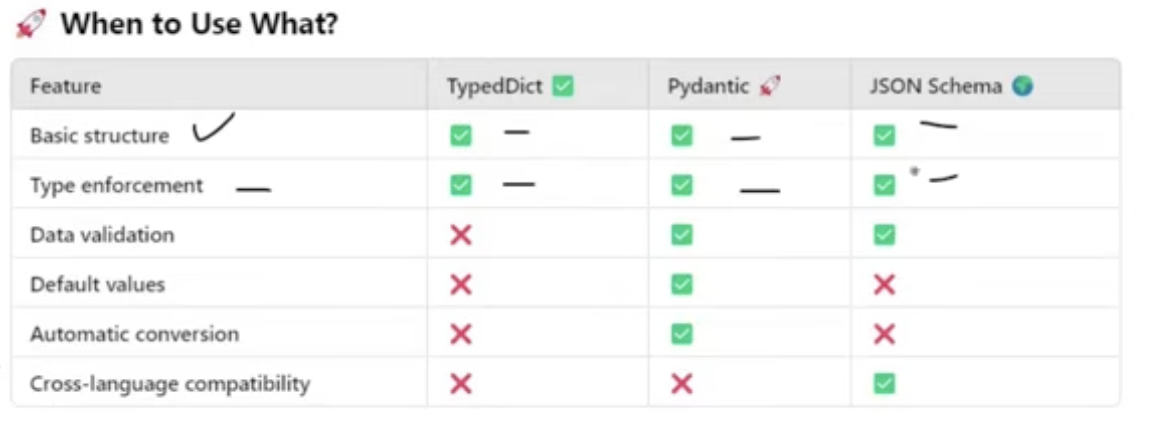

with_structured_output(): it can be used in different ways depending on what the model/provider supports.

In [ ]:
        #              LLM
        #               |
        #   with_structured_output()
        #               |
        #      ┌────────┴────────┐
        #      ↓                 ↓
        #  JSON Mode       Function Calling
        #      ↓                 ↓
        # JSON format       Function call
        #                        ↓
        #                  Function arguments
        #                        ↓
        #                       Tool (Used in Agents)

# JSON mode → structured response/data
# Function calling → structured tool/function invocation

# Claude / Gemini → JSON mode
# OpenAI → function calling

LLM/provider can use different mechanisms internally to produce structured information.

Function Calling


function calling -> function call (args)

This is a different mechanism. Here, the model doesn't necessarily just return ordinary JSON as its final response.

Instead, the model can produce a tool/function call with arguments.

For example, imagine you have:

def calculate_square_root(number):
                            
                            ...

The user asks: "What is the square root of 25?"

The model can determine that it should call:

calculate_square_root

with arguments:

{

    "number": 25

}

So the flow becomes:

User -> "What is square root of 25?" -> LLM -> Function call -> calculate_square_root(number=25)-> Tool executes -> Result

connect function calling with agents.